In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

# Airports we care about
TARGET_AIRPORTS = ["SFO", "JFK", "ORD", "LAX", "ATL", "BOS", "DEN", "SEA", "MIA", "LGA"]

# Carriers we care about
TARGET_CARRIERS = ["DL", "UA", "AA", "B6", "WN"]

DATA_DIR = Path("../data")

### Load Data and Concatenate Dataframes

In [2]:
csv_files = list(DATA_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}")

KEEP_COLS = [
    "YEAR", "QUARTER", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK",
    "FL_DATE", "MKT_CARRIER", "OP_CARRIER", "TAIL_NUM",
    "ORIGIN", "DEST",
    "CRS_DEP_TIME", "DEP_DELAY", "DEP_DEL15",
    "CRS_ARR_TIME", "ARR_DELAY", "ARR_DEL15",
    "CANCELLED", "DIVERTED",
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
    "LATE_AIRCRAFT_DELAY", "DISTANCE"
]

dfs = []

for f in csv_files:

    file = pd.read_csv(f, usecols=lambda c: c in KEEP_COLS, low_memory=False)

    dfs.append(file)

raw_full_df = pd.concat(dfs, ignore_index=True)

print(f"\n Total: {len(raw_full_df)} rows")

Found 4 CSV files in ../data

 Total: 2607478 rows


### Filter to target airpors / carriers and parse datetime values

In [3]:
mask = (
    raw_full_df["ORIGIN"].isin(TARGET_AIRPORTS) &
    raw_full_df["DEST"].isin(TARGET_AIRPORTS) & 
    raw_full_df["MKT_CARRIER"].isin(TARGET_CARRIERS) &
    (raw_full_df["DIVERTED"] == 0)
)

trimmed_df = raw_full_df[mask].copy()

trimmed_df["FL_DATE"] = pd.to_datetime(trimmed_df["FL_DATE"], format="%m/%d/%Y %I:%M:%S %p")

print(f"After filtering: {len(trimmed_df):,} rows")
print(f"Routes: {trimmed_df.groupby(['ORIGIN','DEST']).size().shape[0]}")
print(f"Date range: {trimmed_df['FL_DATE'].min()} → {trimmed_df['FL_DATE'].max()}")

trimmed_df["DEP_HOUR"] = trimmed_df["CRS_DEP_TIME"].astype(str).str.zfill(4).str[:2].astype(int)
trimmed_df["ARR_HOUR"] = trimmed_df["CRS_ARR_TIME"].astype(str).str.zfill(4).str[:2].astype(int)

# Target variable — ensure it's binary int
trimmed_df["DEP_DEL15"] = trimmed_df["DEP_DEL15"].fillna(0).astype(int)

# Fill delay component nulls with 0 (they're null when there's no delay)
for col in ["CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY", "LATE_AIRCRAFT_DELAY"]:
    trimmed_df[col] = trimmed_df[col].fillna(0)

print(trimmed_df[["FL_DATE", "DEP_HOUR", "DEP_DEL15", "WEATHER_DELAY"]].head())
print(f"\nOverall delay rate: {trimmed_df['DEP_DEL15'].mean():.1%}")

After filtering: 128,333 rows
Routes: 82
Date range: 2025-01-01 00:00:00 → 2025-10-31 00:00:00
      FL_DATE  DEP_HOUR  DEP_DEL15  WEATHER_DELAY
0  2025-04-01         6          1            0.0
1  2025-04-01        22          0            0.0
6  2025-04-01        22          1            0.0
40 2025-04-01        18          1            0.0
41 2025-04-01        11          1            0.0

Overall delay rate: 22.0%


### Route-level aggregate statistics

In [4]:
#Ontime rate by route
route_stats = (
    trimmed_df.groupby(["ORIGIN", "DEST"])
    .agg(
        route_ontime_rate = ("DEP_DEL15", lambda x: 1-x.mean()),
        route_median_delay = ("DEP_DELAY", "median"),
        route_flights = ("DEP_DEL15", "count")
    )
    .reset_index()
)

#Ontime rate by carrier + route
carrier_route_stats = (
    trimmed_df.groupby(["MKT_CARRIER", "ORIGIN", "DEST"])
    .agg(
        carrier_route_ontime_rate = (f"DEP_DEL15", lambda x: 1-x.mean())
    )
    .reset_index()
)

# On-time rate by departure hour (captures peak vs off-peak)
hour_stats = (
    trimmed_df.groupby("DEP_HOUR")
    .agg(hour_ontime_rate = ("DEP_DEL15", lambda x: 1 - x.mean()))
    .reset_index()
)

print(route_stats.sort_values("route_ontime_rate").head(10))

   ORIGIN DEST  route_ontime_rate  route_median_delay  route_flights
26    DEN  SFO           0.687314                 2.0           1679
49    MIA  BOS           0.692821                 0.0           1198
19    DEN  BOS           0.697971                 1.0           1331
48    MIA  ATL           0.711075                 0.0           1824
58    ORD  BOS           0.711900                -1.0           2395
0     ATL  BOS           0.716163                 0.0           1522
53    MIA  LGA           0.719008                 0.0           1815
2     ATL  JFK           0.722082                 2.0           1191
4     ATL  LGA           0.722976                 0.0           2285
55    MIA  SEA           0.725100                 0.0            251


### Inbound aircraft delays

In [5]:
# Sort by tail number and datetime to find each flight's prior leg
df = trimmed_df.sort_values(["TAIL_NUM", "FL_DATE", "CRS_DEP_TIME"])

# Shift within each tail number group to get the previous leg's arrival delay
df["prev_arr_delay"] = (
    df.groupby("TAIL_NUM")["ARR_DELAY"]
    .shift(1)
    .fillna(0)
    .clip(lower=0)   # only positive delays carry forward
)

# Only keep if it's the same day (different day = overnight, delay resets)
df["prev_fl_date"] = df.groupby("TAIL_NUM")["FL_DATE"].shift(1)
df["prev_arr_delay"] = df["prev_arr_delay"].where(
    df["FL_DATE"] == df["prev_fl_date"], 0
)

print(f"Flights with inbound delay > 0: {(df['prev_arr_delay'] > 0).sum():,}.  Percentage: {(df['prev_arr_delay'] > 0).mean():.1%}")


Flights with inbound delay > 0: 16,439.  Percentage: 12.8%


### Join route stats onto the primary df

In [6]:
df = df.merge(route_stats[["ORIGIN", "DEST", "route_ontime_rate", "route_median_delay"]], on=["ORIGIN", "DEST"], how="left")

df = df.merge(carrier_route_stats, on=["MKT_CARRIER", "ORIGIN", "DEST"], how="left")

df = df.merge(hour_stats, on="DEP_HOUR", how="left")

#Fill any nulls from the joins (assume 75% overall route ontime rate)
df["route_ontime_rate"] = df["route_ontime_rate"].fillna(0.75)
df["carrier_route_ontime_rate"] = df["carrier_route_ontime_rate"].fillna(0.75)
df["hour_ontime_rate"] = df["hour_ontime_rate"].fillna(0.75)

print(f"Final feature set: {len(df):,} rows, {len(df.columns)} columns")
print(df[["ORIGIN","DEST","MKT_CARRIER","DEP_HOUR","DEP_DEL15",
          "route_ontime_rate","prev_arr_delay"]].head())


Final feature set: 128,333 rows, 32 columns
  ORIGIN DEST MKT_CARRIER  DEP_HOUR  DEP_DEL15  route_ontime_rate  \
0    BOS  ATL          DL        14          0           0.771560   
1    ATL  DEN          DL        18          0           0.766967   
2    DEN  ATL          DL         6          0           0.743990   
3    ATL  BOS          DL        22          0           0.716163   
4    BOS  ATL          DL         8          0           0.771560   

   prev_arr_delay  
0             0.0  
1             0.0  
2             0.0  
3            19.0  
4             0.0  


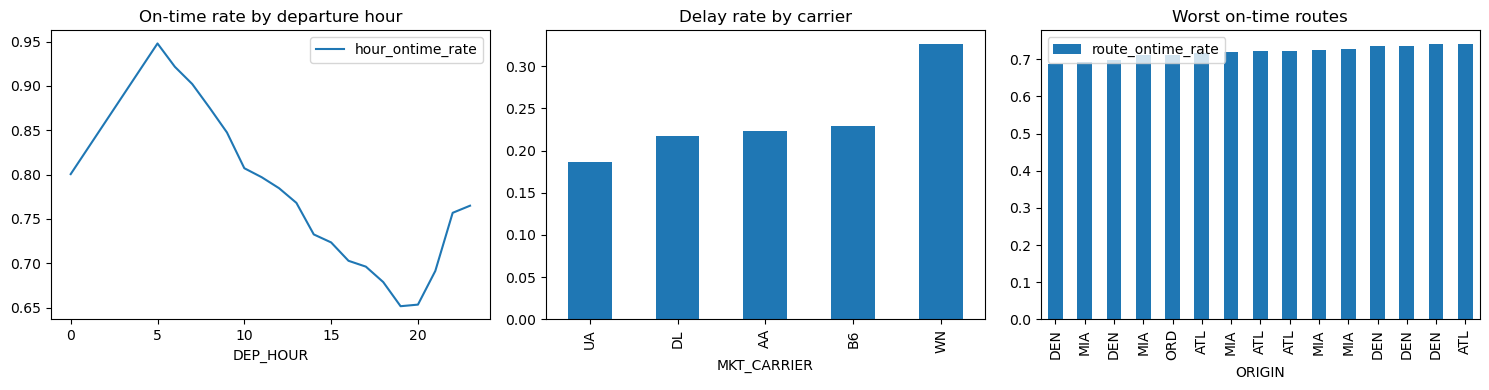

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Delay rate by hour
hour_stats.plot(x="DEP_HOUR", y="hour_ontime_rate", ax=axes[0], 
                title="On-time rate by departure hour")

# Delay rate by carrier
df.groupby("MKT_CARRIER")["DEP_DEL15"].mean().sort_values().plot(
    kind="bar", ax=axes[1], title="Delay rate by carrier")

# Delay rate by route
route_stats.sort_values("route_ontime_rate").head(15).plot(
    x="ORIGIN", y="route_ontime_rate", kind="bar", 
    ax=axes[2], title="Worst on-time routes")

plt.tight_layout()
plt.show()

### Backfill weather data

In [8]:
import sys
import os
sys.path.append(".")

from pirateWeather import PirateWeatherFetcher
from dotenv import load_dotenv

load_dotenv('.env')
API_KEY = os.getenv("PIRATE_WEATHER_API_KEY")

fetcher = PirateWeatherFetcher(API_KEY)

df["FL_DATE_STR"] = df["FL_DATE"].astype(str)

df["DEP_HOUR"]     = df["CRS_DEP_TIME"].astype(str).str.zfill(4).str[:2].astype(int)
df["ARR_HOUR"]     = df["CRS_ARR_TIME"].astype(str).str.zfill(4).str[:2].astype(int)
df["DEP_HOUR_STR"] = df["DEP_HOUR"].astype(str).str.zfill(2)
df["ARR_HOUR_STR"] = df["ARR_HOUR"].astype(str).str.zfill(2)


combos_origin = df.groupby(["ORIGIN", "FL_DATE_STR", "DEP_HOUR_STR"]).size()
combos_dest   = df.groupby(["DEST",   "FL_DATE_STR", "ARR_HOUR_STR"]).size()

print("Number of unique origin-date-hour combos:", len(combos_origin))
print("Number of unique dest-date-hour combos:",   len(combos_dest))

all_combos = set(
    list(combos_origin.index) + 
    [(d, dt, h) for d, dt, h in combos_dest.index]
)


2026-05-27 12:46:21,764 INFO Cache initialized at weather_cache.db


Number of unique origin-date-hour combos: 21831
Number of unique dest-date-hour combos: 23370


In [9]:
import random

API_BUDGET = 20

random.seed(42)
combo_list   = list(all_combos)
sampled_combos = set(random.sample(combo_list, min(API_BUDGET, len(combo_list))))

# Then filter flights to only those whose combos were sampled
df_sample = df[
    df.apply(lambda r: (r["ORIGIN"], r["FL_DATE_STR"], r["DEP_HOUR_STR"]) 
             in sampled_combos, axis=1)
].copy()

print(f"Sampled combos: {len(sampled_combos):,}")
print(f"Flights in sample: {len(df_sample):,}")

Sampled combos: 20
Flights in sample: 109


In [10]:
wx_df = fetcher.backfill_from_bts(
    df_sample,
    airports=TARGET_AIRPORTS,
    date_col="FL_DATE_STR",
    dep_time_col="CRS_DEP_TIME",
    arr_time_col="CRS_ARR_TIME",
)

print(f"\nWeather records returned: {len(wx_df):,}")
wx_df.head()

2026-05-27 12:46:22,358 INFO Processing 109 flights across 10 airports
2026-05-27 12:46:22,360 INFO Found 102 unique (airport, date, hour) combos
2026-05-27 12:46:22,360 INFO Progress: 0/102
2026-05-27 12:46:27,672 INFO Success: ATL 2025-01-16 18
2026-05-27 12:46:33,549 INFO Success: ATL 2025-01-27 18
2026-05-27 12:46:40,002 INFO Success: ATL 2025-01-28 22
2026-05-27 12:46:45,486 INFO Success: ATL 2025-04-19 09
2026-05-27 12:46:51,123 INFO Success: ATL 2025-04-22 12
2026-05-27 12:46:55,885 INFO Success: ATL 2025-04-22 13
2026-05-27 12:47:01,025 INFO Success: ATL 2025-04-22 16
2026-05-27 12:47:07,010 INFO Success: ATL 2025-07-02 11
2026-05-27 12:47:12,747 INFO Success: ATL 2025-07-12 16
2026-05-27 12:47:18,565 INFO Success: ATL 2025-07-15 11
2026-05-27 12:47:24,914 INFO Success: ATL 2025-07-20 21
2026-05-27 12:47:29,318 INFO Success: ATL 2025-10-12 18
2026-05-27 12:47:35,295 INFO Success: ATL 2025-10-16 14
2026-05-27 12:47:41,499 INFO Success: ATL 2025-10-24 21
2026-05-27 12:47:46,415 I


Weather records returned: 102


,unix_time,precip_prob,precip_intensity,wind_speed,wind_gust,wind_bearing,visibility,cloud_cover,temperature,summary,airport,fl_date,hour
0,1737068400,0,0.0000,7.35,17.95,265,10,0.00,53.54,Clear,ATL,2025-04-22,18
1,1738018800,0,0.0007,6.71,14.62,292,10,1.00,49.10,Possible Drizzle,ATL,2025-04-22,18
2,1738119600,0,0.0000,9.30,15.55,252,10,0.01,45.38,Clear,ATL,2025-04-22,22
3,1745067600,0,0.0000,3.67,11.42,167,10,0.91,62.46,Overcast,ATL,2025-04-22,09
4,1745337600,0,0.0060,1.45,15.58,359,10,1.00,69.47,Drizzle,ATL,2025-04-22,12


In [11]:
# Standardize the hour column from the weather df for joining
wx_df["hour_str"] = wx_df["hour"].astype(str).str.zfill(2)

# Origin weather join
wx_origin = wx_df.rename(columns={
    "airport":          "ORIGIN",
    "fl_date":          "FL_DATE_STR",
    "hour_str":         "DEP_HOUR_STR",
    "precip_prob":      "origin_precip_prob",
    "precip_intensity": "origin_precip_intensity",
    "wind_speed":       "origin_wind_speed",
    "wind_gust":        "origin_wind_gust",
    "visibility":       "origin_visibility",
    "cloud_cover":      "origin_cloud_cover",
    "temperature":      "origin_temperature",
})

# Dest weather join
wx_dest = wx_df.rename(columns={
    "airport":          "DEST",
    "fl_date":          "FL_DATE_STR",
    "hour_str":         "ARR_HOUR_STR",
    "precip_prob":      "dest_precip_prob",
    "precip_intensity": "dest_precip_intensity",
    "wind_speed":       "dest_wind_speed",
    "wind_gust":        "dest_wind_gust",
    "visibility":       "dest_visibility",
    "cloud_cover":      "dest_cloud_cover",
    "temperature":      "dest_temperature",
})

origin_wx_cols = ["ORIGIN","FL_DATE_STR","DEP_HOUR_STR",
                  "origin_precip_prob","origin_precip_intensity",
                  "origin_wind_speed","origin_wind_gust",
                  "origin_visibility","origin_cloud_cover","origin_temperature"]

dest_wx_cols   = ["DEST","FL_DATE_STR","ARR_HOUR_STR",
                  "dest_precip_prob","dest_precip_intensity",
                  "dest_wind_speed","dest_wind_gust",
                  "dest_visibility","dest_cloud_cover","dest_temperature"]

df_sample = df_sample.merge(wx_origin[origin_wx_cols],
                             on=["ORIGIN","FL_DATE_STR","DEP_HOUR_STR"],
                             how="left")

df_sample = df_sample.merge(wx_dest[dest_wx_cols],
                             on=["DEST","FL_DATE_STR","ARR_HOUR_STR"],
                             how="left")

# Fill weather nulls
weather_cols = [c for c in df_sample.columns if c.startswith(("origin_","dest_"))]
for col in weather_cols:
    if any(x in col for x in ["precip","cloud"]):
        df_sample[col] = df_sample[col].fillna(0)
    elif "visibility" in col:
        df_sample[col] = df_sample[col].fillna(10)
    else:
        df_sample[col] = df_sample[col].fillna(df_sample[col].median())

join_rate = df_sample["origin_precip_prob"].notna().mean()
print(f"Weather join rate:  {join_rate:.1%}")
print(f"Rows after join:    {len(df_sample):,}")
print(f"Weather null check:\n{df_sample[weather_cols].isnull().sum()}")

Weather join rate:  100.0%
Rows after join:    118
Weather null check:
origin_precip_prob         0
origin_precip_intensity    0
origin_wind_speed          0
origin_wind_gust           0
origin_visibility          0
origin_cloud_cover         0
origin_temperature         0
dest_precip_prob           0
dest_precip_intensity      0
dest_wind_speed            0
dest_wind_gust             0
dest_visibility            0
dest_cloud_cover           0
dest_temperature           0
dtype: int64


In [12]:
FEATURES = [
    # Temporal
    "MONTH", "DAY_OF_WEEK", "DEP_HOUR",
    # Route/carrier
    "ORIGIN", "DEST", "MKT_CARRIER",
    # Historical performance
    "route_ontime_rate",
    "carrier_route_ontime_rate",
    "hour_ontime_rate",
    "route_median_delay",
    # Operational
    "prev_arr_delay",
    "DISTANCE",
    # Origin weather
    "origin_precip_prob",
    "origin_wind_speed",
    "origin_wind_gust",
    "origin_visibility",
    "origin_cloud_cover",
    "origin_temperature",
    # Dest weather
    "dest_precip_prob",
    "dest_wind_speed",
    "dest_visibility",
    "dest_cloud_cover",
]

TARGET = "DEP_DEL15"

model_df = df_sample[FEATURES + [TARGET]].dropna(subset=[TARGET])

print(f"Model dataset: {len(model_df):,} rows × {len(FEATURES)} features")
print(f"Delay rate:    {model_df[TARGET].mean():.1%}")
print(f"\nFeature nulls:\n{model_df[FEATURES].isnull().sum()[lambda x: x > 0]}")

real_weather = (df_sample["origin_precip_prob"] != 0).sum()
print(f"Flights with real weather data: {real_weather:,} of {len(df_sample):,}")



Model dataset: 118 rows × 22 features
Delay rate:    18.6%

Feature nulls:
Series([], dtype: int64)
Flights with real weather data: 0 of 118


In [13]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Label encode categoricals
le_origin  = LabelEncoder().fit(model_df["ORIGIN"])
le_dest    = LabelEncoder().fit(model_df["DEST"])
le_carrier = LabelEncoder().fit(model_df["MKT_CARRIER"])

model_df = model_df.copy()
model_df["ORIGIN"]      = le_origin.transform(model_df["ORIGIN"])
model_df["DEST"]        = le_dest.transform(model_df["DEST"])
model_df["MKT_CARRIER"] = le_carrier.transform(model_df["MKT_CARRIER"])

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,          # reduced from 63 given smaller dataset
    min_child_samples=10,   # reduced to handle smaller dataset
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(100)
    ]
)

probs = model.predict_proba(X_test)[:, 1]
auc   = roc_auc_score(y_test, probs)
print(f"\nTest AUC: {auc:.4f}")
print(classification_report(y_test, (probs > 0.5).astype(int),
      target_names=["On time", "Delayed"]))

Train: 94 | Test: 24
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[38]	valid_0's binary_logloss: 0.453539

Test AUC: 0.7875
              precision    recall  f1-score   support

     On time       0.90      0.90      0.90        20
     Delayed       0.50      0.50      0.50         4

    accuracy                           0.83        24
   macro avg       0.70      0.70      0.70        24
weighted avg       0.83      0.83      0.83        24



In [16]:
import pickle
import json

# Feature importance
importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))

# Export everything FastAPI needs
with open("../model/delay_model.pkl", "wb") as f:
    pickle.dump(model, f)

encoders = {
    "origin":  list(le_origin.classes_),
    "dest":    list(le_dest.classes_),
    "carrier": list(le_carrier.classes_),
}
with open("../model/label_encoders.json", "w") as f:
    json.dump(encoders, f)

with open("../model/feature_list.json", "w") as f:
    json.dump(FEATURES, f)

# Also save route stats for FastAPI to use in inference
route_stats.to_csv("../model/route_stats.csv", index=False)
carrier_route_stats.to_csv("../model/carrier_route_stats.csv", index=False)
hour_stats.to_csv("../model/hour_stats.csv", index=False)

print("Exported to ../model/:")
print("  delay_model.pkl")
print("  label_encoders.json")
print("  feature_list.json")
print("  route_stats.csv")
print("  carrier_route_stats.csv")
print("  hour_stats.csv")


                  feature  importance
carrier_route_ontime_rate          51
                 DISTANCE          41
           prev_arr_delay          33
                    MONTH          31
        route_ontime_rate          17
              DAY_OF_WEEK          15
              MKT_CARRIER          14
       route_median_delay          13
                 DEP_HOUR          11
                   ORIGIN           9
                     DEST           7
         hour_ontime_rate           3
       origin_temperature           0
          dest_visibility           0
          dest_wind_speed           0
         dest_precip_prob           0
        origin_wind_speed           0
       origin_cloud_cover           0
        origin_visibility           0
         origin_wind_gust           0
       origin_precip_prob           0
         dest_cloud_cover           0
Exported to ../model/:
  delay_model.pkl
  label_encoders.json
  feature_list.json
  route_stats.csv
  carrier_route_stats.csv